# 03 – Análise Exploratória (EDA) da Base Limpa
## UCI SECOM Dataset – Manufacturing Quality Analytics

**Objetivo desta etapa:**
- Carregar a base limpa (`secom_clean.csv`)
- Analisar a distribuição de PASS vs FAIL
- Explorar estatísticas básicas dos sensores
- Investigar relações entre sensores e o resultado (FAIL)
- Gerar insights para o dashboard e para um futuro modelo de classificação

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")

# Caminhos
BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), ".."))
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")

CLEAN_FILE    = os.path.join(PROCESSED_DIR, "secom_clean.csv")

print("BASE_DIR   :", BASE_DIR)
print("CLEAN_FILE :", CLEAN_FILE)
print("Arquivo existe?", os.path.exists(CLEAN_FILE))

BASE_DIR   : /Users/dtp/Desktop/projetos_BI/projeto-02-quality-analytics-secom
CLEAN_FILE : /Users/dtp/Desktop/projetos_BI/projeto-02-quality-analytics-secom/data/processed/secom_clean.csv
Arquivo existe? True


## 1. Carregar a base limpa

Aqui usamos o resultado da etapa de transformação:
- Sensores com >50% de missing removidos
- Missing remanescentes imputados pela mediana
- Nenhum NaN residual

In [5]:
df = pd.read_csv(CLEAN_FILE)

print(f"Shape da base limpa: {df.shape[0]} linhas × {df.shape[1]} colunas")
df.head()

Shape da base limpa: 1567 linhas × 566 colunas


,Unit_ID,Label,Timestamp,Result,Sensor_001,Sensor_002,Sensor_003,Sensor_004,Sensor_005,Sensor_006,...,Sensor_577,Sensor_578,Sensor_583,Sensor_584,Sensor_585,Sensor_586,Sensor_587,Sensor_588,Sensor_589,Sensor_590
0,1,-1,2008-07-19 11:55:00,FAIL,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,...,1.6765,14.9509,0.5005,0.0118,0.0035,2.3630,0.0205,0.0148,0.0046,71.9005
1,2,-1,2008-07-19 12:32:00,FAIL,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,...,1.1065,10.9003,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,3,1,2008-07-19 13:17:00,PASS,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,...,2.0952,9.2721,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,4,-1,2008-07-19 14:43:00,FAIL,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,...,1.7585,8.5831,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,5,-1,2008-07-19 15:22:00,FAIL,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,...,1.6597,10.9698,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [7]:
df.info()
print("\nExistem NaNs na base?", df.isnull().any().any())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 566 entries, Unit_ID to Sensor_590
dtypes: float64(562), int64(2), object(2)
memory usage: 6.8+ MB

Existem NaNs na base? False


## 2. Distribuição de PASS vs FAIL

Primeiro, confirmamos a proporção de casos FAIL vs PASS na base final
(e verificamos se a transformação não alterou essa distribuição).

=== Distribuição PASS / FAIL ===
FAIL: 1463 unidades (93.4%)
PASS: 104 unidades (6.6%)


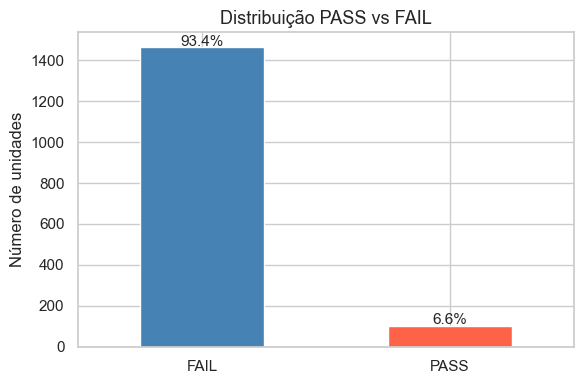

In [10]:
counts = df["Result"].value_counts()
pct    = df["Result"].value_counts(normalize=True) * 100

print("=== Distribuição PASS / FAIL ===")
for label in counts.index:
    print(f"{label}: {counts[label]} unidades ({pct[label]:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", color=["steelblue", "tomato"], ax=ax)
ax.set_title("Distribuição PASS vs FAIL", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Número de unidades")
ax.set_xticklabels(counts.index, rotation=0)
for i, v in enumerate(counts):
    ax.text(i, v + 5, f"{pct.iloc[i]:.1f}%", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

## 3. Estrutura dos sensores

Vamos separar:
- colunas de controle (`Unit_ID`, `Label`, `Timestamp`, `Result`)
- colunas de sensores (`Sensor_*`)

e explorar estatísticas básicas dos sensores.

In [13]:
control_cols = ["Unit_ID", "Label", "Timestamp", "Result"]
sensor_cols  = [c for c in df.columns if c.startswith("Sensor_")]

print("Colunas de controle:", control_cols)
print("Número de sensores :", len(sensor_cols))
print("Exemplos de sensores:", sensor_cols[:5])

Colunas de controle: ['Unit_ID', 'Label', 'Timestamp', 'Result']
Número de sensores : 562
Exemplos de sensores: ['Sensor_001', 'Sensor_002', 'Sensor_003', 'Sensor_004', 'Sensor_005']


In [15]:
# Estatísticas descritivas dos sensores
sensor_desc = df[sensor_cols].describe().T  # T para transpor (linhas = sensores)
sensor_desc.head()

,count,mean,std,min,25%,50%,75%,max
Sensor_001,1567.0,3014.441551,73.480841,2743.2400,2966.66500,3011.4900,3056.5400,3356.3500
Sensor_002,1567.0,2495.866110,80.228143,2158.7500,2452.88500,2499.4050,2538.7450,2846.4400
Sensor_003,1567.0,2200.551958,29.380973,2060.6600,2181.09995,2201.0667,2218.0555,2315.2667
Sensor_004,1567.0,1395.383474,439.837330,0.0000,1083.88580,1285.2144,1590.1699,3715.0417
Sensor_005,1567.0,4.171281,56.103721,0.6815,1.01770,1.3168,1.5188,1114.5366


### Sensores com maior e menor variabilidade

Sensores com desvio-padrão muito baixo tendem a ter pouca informação
(variáveis quase constantes). Já sensores com alta variabilidade podem
ser mais informativos para detectar falhas.

In [18]:
# Ordena por desvio-padrão
sensor_desc_sorted = sensor_desc.sort_values("std", ascending=False)

print("Top 10 sensores com MAIOR desvio-padrão:")
sensor_desc_sorted.head(10)[["mean", "std", "min", "max"]]

Top 10 sensores com MAIOR desvio-padrão:


,mean,std,min,max
Sensor_163,4793.308870,6550.267099,0.0000,36871.0000
Sensor_162,4064.996171,4236.854877,0.0000,37943.0000
Sensor_298,2340.883483,3225.321542,0.0000,18520.4683
Sensor_025,-298.317538,2900.846582,-14804.5000,14106.0000
Sensor_297,1878.364532,1973.997717,0.0000,15559.9525
Sensor_024,-3806.318177,1379.280633,-9986.7500,2363.0000
Sensor_160,882.349075,982.458855,0.0000,7791.0000
Sensor_022,-5618.272176,626.430997,-7150.2500,0.0000
Sensor_161,555.196554,574.456703,0.0000,4170.0000
Sensor_205,32.095412,564.021108,0.0429,9998.4483


In [20]:
print("Top 10 sensores com MENOR desvio-padrão:")
sensor_desc_sorted.tail(10)[["mean", "std", "min", "max"]]

Top 10 sensores com MENOR desvio-padrão:


,mean,std,min,max
Sensor_258,0.0,0.0,0.0,0.0
Sensor_466,0.0,0.0,0.0,0.0
Sensor_257,0.0,0.0,0.0,0.0
Sensor_459,0.0,0.0,0.0,0.0
Sensor_244,0.0,0.0,0.0,0.0
Sensor_462,0.0,0.0,0.0,0.0
Sensor_463,0.0,0.0,0.0,0.0
Sensor_464,0.0,0.0,0.0,0.0
Sensor_465,0.0,0.0,0.0,0.0
Sensor_316,0.0,0.0,0.0,0.0


## 4. Relação básica entre sensores e FAIL

Como temos muitos sensores, vamos começar olhando:

1. Diferença de média de alguns sensores entre PASS e FAIL  
2. Correlação de Pearson dos sensores com a variável alvo (FAIL vs PASS)

Para isso, criamos uma variável binária auxiliar:
- `Target_FAIL = 1` se Result = FAIL
- `Target_FAIL = 0` se Result = PASS

In [23]:
df["Target_FAIL"] = (df["Result"] == "FAIL").astype(int)

df[["Result", "Target_FAIL"]].head()

,Result,Target_FAIL
0,FAIL,1
1,FAIL,1
2,PASS,0
3,FAIL,1
4,FAIL,1


In [25]:
# Médias por grupo (PASS vs FAIL) para alguns sensores
sample_sensors = sensor_cols[:10]  # pega os 10 primeiros só como exemplo

group_means = df.groupby("Result")[sample_sensors].mean().T
group_means.rename(columns={"FAIL": "mean_FAIL", "PASS": "mean_PASS"}, inplace=True)
group_means["diff_FAIL_minus_PASS"] = group_means["mean_FAIL"] - group_means["mean_PASS"]

group_means.sort_values("diff_FAIL_minus_PASS", ascending=False)

Result,mean_FAIL,mean_PASS,diff_FAIL_minus_PASS
Sensor_004,1398.198657,1355.781435,42.417222
Sensor_001,3014.933137,3007.526250,7.406887
Sensor_005,4.375149,1.303405,3.071744
Sensor_002,2495.920465,2495.101490,0.818974
Sensor_003,2200.559783,2200.441877,0.117906
Sensor_010,-0.000716,-0.002608,0.001892
Sensor_006,100.000000,100.000000,0.000000
Sensor_008,0.121794,0.122257,-0.000463
Sensor_009,1.462308,1.470619,-0.008311
Sensor_007,101.089854,101.490972,-0.401118


In [27]:
# Correlação de Pearson entre sensores e Target_FAIL
corrs = df[sensor_cols + ["Target_FAIL"]].corr()["Target_FAIL"].drop("Target_FAIL")

# Top sensores positivamente correlacionados com FAIL
top_pos = corrs.sort_values(ascending=False).head(10)

# Top sensores negativamente correlacionados (protegem contra FAIL)
top_neg = corrs.sort_values(ascending=True).head(10)

print("Top 10 sensores mais positivamente correlacionados com FAIL:")
top_pos

Top 10 sensores mais positivamente correlacionados com FAIL:


Sensor_029    0.106987
Sensor_317    0.089385
Sensor_126    0.083644
Sensor_027    0.080579
Sensor_181    0.078631
Sensor_123    0.078326
Sensor_453    0.077085
Sensor_128    0.075128
Sensor_023    0.073646
Sensor_015    0.068968
Name: Target_FAIL, dtype: float64

In [29]:
print("Top 10 sensores mais negativamente correlacionados com FAIL:")
top_neg

Top 10 sensores mais negativamente correlacionados com FAIL:


Sensor_060   -0.156008
Sensor_104   -0.151230
Sensor_511   -0.131662
Sensor_349   -0.130807
Sensor_432   -0.119936
Sensor_435   -0.111312
Sensor_431   -0.109115
Sensor_022   -0.108333
Sensor_436   -0.108260
Sensor_437   -0.106119
Name: Target_FAIL, dtype: float64

In [31]:
# Pega alguns sensores dos top correlacionados
top_sensors_to_plot = list(top_pos.index[:3])  # 3 mais correlacionados com FAIL

print("Sensores selecionados para plot:", top_sensors_to_plot)

Sensores selecionados para plot: ['Sensor_029', 'Sensor_317', 'Sensor_126']


/var/folders/gc/3230_1m533d7q6l8f1wvphr40000gn/T/ipykernel_1125/532414591.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Result", y=sensor, ax=ax, palette={"PASS": "steelblue", "FAIL": "tomato"})
/var/folders/gc/3230_1m533d7q6l8f1wvphr40000gn/T/ipykernel_1125/532414591.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Result", y=sensor, ax=ax, palette={"PASS": "steelblue", "FAIL": "tomato"})
/var/folders/gc/3230_1m533d7q6l8f1wvphr40000gn/T/ipykernel_1125/532414591.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.box

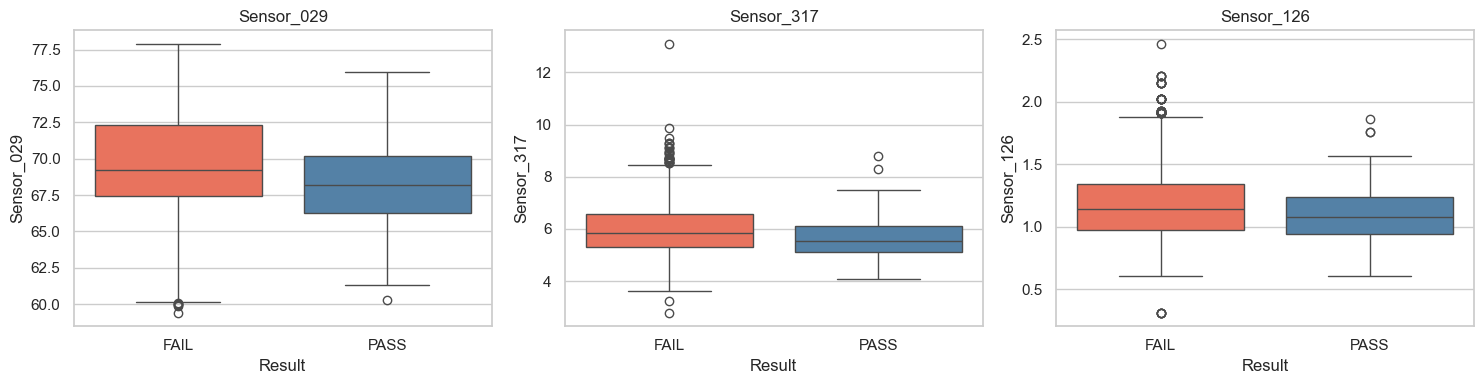

In [33]:
# Boxplots PASS vs FAIL para esses sensores
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, sensor in zip(axes, top_sensors_to_plot):
    sns.boxplot(data=df, x="Result", y=sensor, ax=ax, palette={"PASS": "steelblue", "FAIL": "tomato"})
    ax.set_title(sensor)

plt.tight_layout()
plt.show()

## 5. Interpretação inicial

Com base na correlação e nos boxplots:

- Alguns sensores mostram diferenças claras de distribuição entre PASS e FAIL.
- Esses sensores podem ser bons candidatos a features importantes em um modelo de classificação.
- Em termos de negócio, eles são potenciais “indicadores de risco” de falha de qualidade.

Na narrativa do projeto, podemos dizer que:
> “Identifiquei um subconjunto de sensores com correlação significativa com o resultado FAIL, que serão priorizados tanto nos dashboards quanto em um futuro modelo de predição de defeitos.”

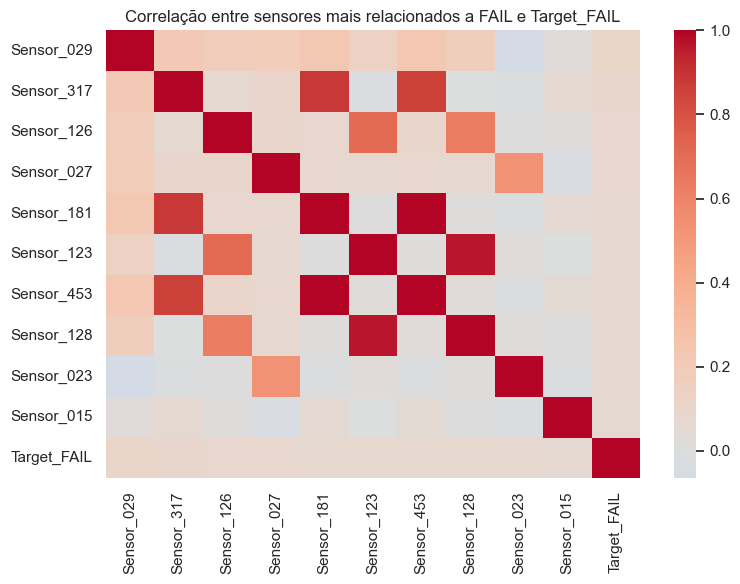

In [40]:
# Heatmap pequeno com os 10 sensores mais correlacionados com FAIL
selected = list(top_pos.index[:10]) + ["Target_FAIL"]

corr_matrix = df[selected].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0)
plt.title("Correlação entre sensores mais relacionados a FAIL e Target_FAIL")
plt.tight_layout()
plt.show()

### Insight 

Pelos números e boxplots dá para enxergar assim:

- **Sensor_029**: em média, valores de FAIL estão um pouco mais altos que os de PASS, com uma dispersão maior em FAIL. Isso combina com a correlação positiva (0,10): quando esse sensor sobe, a chance de FAIL tende a aumentar levemente.

- cSensor_317**: também mostra mediana e distribuição de FAIL ligeiramente acima de PASS, com alguns outliers em FAIL; novamente consistente com uma correlação positiva moderada.

- **Sensor_126**: as distribuições são parecidas, mas FAIL tem mais outliers em níveis mais altos, sugerindo que valores extremos desse sensor estão associados a maior risco de reprovação.
  
**Para usar em entrevista / texto de projeto**, você pode resumir assim:

“Na análise exploratória identifiquei alguns sensores com padrão claramente diferente entre unidades aprovadas e reprovadas. 

Por exemplo, os sensores 029, 317 e 126 apresentam distribuições deslocadas em direção a valores mais altos em casos de FAIL, e estão entre os mais correlacionados positivamente com a variável alvo. 

Esses sensores passam a ser candidatos naturais a indicadores de risco de falha, tanto para o dashboard quanto para um futuro modelo preditivo.”